In [1]:
import sys
sys.path.append("..")

In [2]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import DataLoader

from data_utils.scan_helpers import (
    download_scan_simple_split,
    download_scan_add_prim_split,
    load_scan_split,
    build_vocab,
    PAD,
    BOS,
    EOS,
)

from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    ordered_sequence_token_accuracy,   
    evaluate_ordered_token_accuracy,
    evaluate_teacher_forced_ordered_token_accuracy,
    teacher_forced_ordered_sequence_accuracy,
)

from result_utils.save_results import (
    save_experiment_results,
    load_experiment_results,
)

from result_utils.plot_results import (
    exp3_plot_token_accuracy,
    exp3_plot_sequence_accuracy,
)

from data_utils.scan_dataset import ScanDataset
from data_utils.scan_dataloader import collate_scan_batch

from models.transformer import Transformer

In [ ]:
SEED_BASE = 42

In [ ]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'{device} - {device_name}')

In [ ]:
import time
from contextlib import contextmanager

@contextmanager
def stopwatch(name: str):
    start = time.perf_counter()
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        print(f"[{name}] Elapsed time: {elapsed:.2f} seconds")


## Load SCAN & Create Vocabulary

In [ ]:
scan_dir = download_scan_add_prim_split()

train_inputs, train_outputs = load_scan_split(
    f"{scan_dir}/tasks_train_addprim_jump.txt"
)
test_inputs, test_outputs = load_scan_split(
    f"{scan_dir}/tasks_test_addprim_jump.txt"
)

print(f"Train samples: {len(train_inputs)}")
print(f"Test samples:  {len(test_inputs)}")

In [ ]:
source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

print("Source vocab size:", len(source_vocab))
print("Target vocab size:", len(target_vocab))

## Setup training and evaluation, for the Experiment 3

In [ ]:
from tqdm import tqdm

def train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    device,
    max_samples=100_000,
    grad_clip=1.0,
):
    model.train()
    total_samples = 0
    epoch = 0

    pbar = tqdm(total=max_samples, desc="Training samples")

    while total_samples < max_samples:
        epoch += 1

        for source_seq, target_input, target_output in train_loader:
            if total_samples >= max_samples:
                break

            batch_size = source_seq.size(0)

            source_seq = source_seq.to(device)
            target_input = target_input.to(device)
            target_output = target_output.to(device)

            optimizer.zero_grad()
            logits = model(source_seq, target_input)

            loss = criterion(
                logits.view(-1, logits.size(-1)),
                target_output.view(-1),
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_samples += batch_size
            pbar.update(batch_size)

    pbar.close()
    print("Training complete.")


In [ ]:
num_composed_commands = [1, 2, 4, 8, 16, 32]
dataset_pairs = []

dataset_pairs.append((0, 1, "data/add_prim_split/tasks_train_addprim_jump.txt", "data/add_prim_split/tasks_test_addprim_jump.txt"))
dataset_pairs.append((99, 1, "data/add_prim_split/tasks_train_addprim_turn_left.txt", "data/add_prim_split/tasks_test_addprim_turn_left.txt"))

for p in num_composed_commands:
    for i in range(1, 6):
        p2_train_path_base = f"data/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num{p}_rep{i}.txt"
        p2_test_path_base  = f"data/add_prim_split/with_additional_examples/tasks_test_addprim_complex_jump_num{p}_rep{i}.txt"

        dataset_pairs.append((p, i, p2_train_path_base, p2_test_path_base))

In [ ]:
results = {}
run_accuracies = {}

for p, i, p2_train_path_base, p2_test_path_base in dataset_pairs:
    with stopwatch("=== Experiment 3: {p} composed commands - Sample Number {i} ==="):

        train_inputs, train_outputs = load_scan_split(p2_train_path_base)
        test_inputs, test_outputs   = load_scan_split(p2_test_path_base)

        print(f"Train examples: {len(train_inputs)}")
        print(f"Test examples: {len(test_inputs)}")

        source_vocab = build_vocab(train_inputs)
        target_vocab = build_vocab(train_outputs)

        train_dataset = ScanDataset(
            train_inputs, train_outputs, source_vocab, target_vocab
        )
        test_dataset = ScanDataset(
            test_inputs, test_outputs, source_vocab, target_vocab
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True,
            collate_fn=collate_scan_batch,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=16,
            shuffle=False,
            collate_fn=collate_scan_batch,
        )

        seed = 42 + p
        torch.manual_seed(seed)
        random.seed(seed)
        np.random.seed(seed)

        model = Transformer(
            source_vocab_size=len(source_vocab),
            target_vocab_size=len(target_vocab),
            source_padding_index=PAD,
            target_padding_index=PAD,
            emb_dim=128,
            num_layers=2,
            num_heads=8,
            forward_dim=256,
            dropout=0.15,
            max_sequence_length=512,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
        criterion = nn.CrossEntropyLoss(ignore_index=PAD)

        train_model(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            grad_clip=1.0,
            max_samples=100_000
        )

    # print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
    # final_tok_acc = evaluate_ordered_token_accuracy(model, test_loader, device)
    print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
    final_tok_acc = evaluate_teacher_forced_ordered_token_accuracy(model, test_loader, device)
    print(f"Evaluating sequence accuracy using test set with {len(test_inputs)} commands")
    final_seq_acc = evaluate_sequence_accuracy(model, test_loader, device, use_oracle=False)
    
    print(f"Final (ordered) token accuracy: {final_tok_acc * 100:.2f}%")
    print(f"Final sequence accuracy: {final_seq_acc * 100:.2f}%")

    run_accuracies.setdefault(p, {"seq": [], "tok": []})

    run_accuracies[p]["seq"].append(final_seq_acc)
    run_accuracies[p]["tok"].append(final_tok_acc)

for p_val, accs in run_accuracies.items():
    seq_accs = np.array(accs["seq"])
    tok_accs = np.array(accs["tok"])

    results[p_val] = {
        "seq": {
            "runs": seq_accs.tolist(),
            "mean": float(seq_accs.mean()),
            "std": float(seq_accs.std(ddof=1)) if len(seq_accs) > 1 else 0.0,
        },
        "tok": {
            "runs": tok_accs.tolist(),
            "mean": float(tok_accs.mean()),
            "std": float(tok_accs.std(ddof=1)) if len(tok_accs) > 1 else 0.0,
        },
    }

    print(
        f"\np={p_val} | "
        f"SEQ: {results[p]['seq']['mean']*100:.2f}% ± {results[p]['seq']['std']*100:.2f}% | "
        f"TOK: {results[p]['tok']['mean']*100:.2f}% ± {results[p]['tok']['std']*100:.2f}%"
    )

In [ ]:
for p_val, accs in run_accuracies.items():
    seq_accs = np.array(accs["seq"])
    tok_accs = np.array(accs["tok"])

    results[p_val] = {
        "seq": {
            "runs": seq_accs.tolist(),
            "mean": float(seq_accs.mean()),
            "std": float(seq_accs.std(ddof=1)) if len(seq_accs) > 1 else 0.0,
        },
        "tok": {
            "runs": tok_accs.tolist(),
            "mean": float(tok_accs.mean()),
            "std": float(tok_accs.std(ddof=1)) if len(tok_accs) > 1 else 0.0,
        },
    }

    print(
        f"\np={p_val} | "
        f"SEQ: {results[p_val]['seq']['mean']*100:.2f}% ± {results[p_val]['seq']['std']*100:.2f}% | "
        f"TOK: {results[p_val]['tok']['mean']*100:.2f}% ± {results[p_val]['tok']['std']*100:.2f}%"
    )

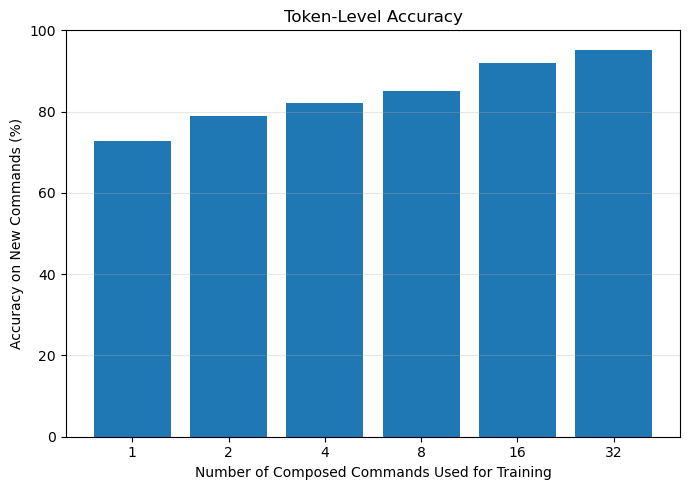

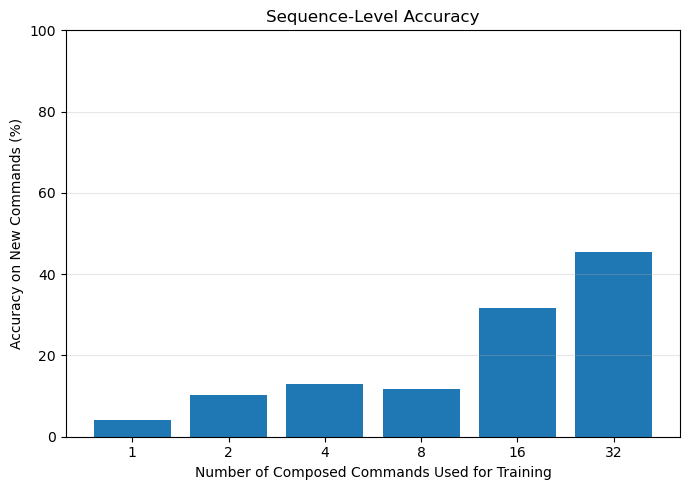

In [5]:
results = load_experiment_results(
    "results/experiment_3/experiment_3_full.171220252000.json"
)

exp3_plot_token_accuracy(results)
exp3_plot_sequence_accuracy(results)


In [ ]:
import matplotlib.pyplot as plt

# Extract k values (ignore p=0 and p=99)
ks = sorted(
    k for k in results.keys()
    if k not in [0, 99]
)

# Extract accuracies
token_means = [results[k]["tok"]["mean"] * 100 for k in ks]
sequence_means = [results[k]["seq"]["mean"] * 100 for k in ks]

# Optional: standard deviations (if you want error bars later)
token_stds = [results[k]["tok"]["std"] * 100 for k in ks]
sequence_stds = [results[k]["seq"]["std"] * 100 for k in ks]

# -------------------------
# Token-level accuracy plot
# -------------------------
plt.figure(figsize=(7, 5))
plt.bar(range(len(ks)), token_means)
plt.xticks(range(len(ks)), ks)
plt.xlabel("Number of Composed Commands Used for Training")
plt.ylabel("Accuracy on New Commands (%)")
plt.title("Token-Level Accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.show()

# ----------------------------
# Sequence-level accuracy plot
# ----------------------------
plt.figure(figsize=(7, 5))
plt.bar(range(len(ks)), sequence_means)
plt.xticks(range(len(ks)), ks)
plt.xlabel("Number of Composed Commands Used for Training")
plt.ylabel("Accuracy on New Commands (%)")
plt.title("Sequence-Level Accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.show()
